# Autocomplete and Autocorrect Data Analytics
## Oasis Infobyte Data Analytics Internship — Task 5

**Autocomplete** predicts the next likely word based on previously typed words or a prefix — e.g. typing "I want" and being offered "to" as a likely continuation.

**Autocorrect** detects a potentially misspelled word and suggests (or automatically applies) a likely correction — e.g. "recieve" → "receive".

NLP techniques are useful for both because they let us learn these patterns statistically from real text rather than hand-coding rules: word co-occurrence frequencies (n-grams) reveal what tends to follow what, and string-similarity measures (edit distance) reveal which "real" words a typo most likely came from.

**This project implements, tests, and compares:**
- Two autocomplete approaches — a **bigram** (1-word-context) and a **trigram** (2-word-context) frequency model.
- Two autocorrect approaches — **pyspellchecker** (a general English dictionary + frequency model) and a **custom Levenshtein-distance corrector** restricted to this project's own corpus vocabulary.

**Major limitations up front** (expanded in detail later in the notebook): both autocomplete models only ever "know" what a single 19th-century novel contains, so their vocabulary and phrasing are narrow and dated compared to a modern keyboard; neither model understands meaning, only frequency; and the autocorrect approaches have no sentence context at all — they correct a word in isolation.

## 1. Import Libraries

In [35]:
import re
import string
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams

from spellchecker import SpellChecker
import textdistance


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

random.seed(42)
np.random.seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Load and Inspect the Corpus

**Source:** *Emma* by Jane Austen (1816), from NLTK's bundled Project Gutenberg corpus (`nltk.corpus.gutenberg`, file `austen-emma.txt`) — the full, public-domain text of a real novel, not a synthetic or toy dataset.

**Why this corpus is suitable:** it's a single, complete, coherent work of substantial length (well over 100,000 words), giving the n-gram models enough real word-sequence data to produce meaningful frequency statistics, while being small enough to process quickly on a laptop. Its dialogue-heavy prose style also means common conversational bigrams/trigrams (e.g. "I am", "it was") appear frequently, which is useful for producing sensible-looking autocomplete predictions.

In [36]:
with open("data/corpus.txt", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Corpus source: Emma by Jane Austen (Project Gutenberg, via NLTK)")
print(f"Characters: {len(raw_text):,}")

Corpus source: Emma by Jane Austen (Project Gutenberg, via NLTK)
Characters: 887,071


In [37]:
print("Sample of the raw corpus:\n")
print(raw_text[:600])

Sample of the raw corpus:

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.  Her mother
had died too long ago for her to have more than an indistinct
remembrance of her caresses; and her place had b


In [38]:
raw_tokens = word_tokenize(raw_text)
print(f"Raw tokens (word_tokenize, includes punctuation marks as separate tokens): {len(raw_tokens):,}")
print(f"Approximate number of lines: {raw_text.count(chr(10)):,}")

Raw tokens (word_tokenize, includes punctuation marks as separate tokens): 191,855
Approximate number of lines: 16,823


### Observation

The corpus is not printed in full (only a short sample above), per the requirement to avoid dumping the entire text. At 887,071 characters and roughly 192,000 raw tokens, this is a substantial single-author corpus — large enough to make bigram and (with more sparsity, as we'll see later) trigram frequency estimates meaningful, without being large enough to require special handling for memory or runtime.

## 3. NLP Preprocessing

The pipeline: **lowercase → tokenize → strip surrounding punctuation → filter to real word tokens**. Each step is applied deliberately, not automatically.

One preprocessing decision needs explaining up front: **stopword removal**. Words like "the", "a", "is", "to", "of", "in" are usually removed in general NLP text analysis (e.g. for a word-frequency chart, where they'd just dominate uninterestingly). But for **autocomplete specifically, removing them would hurt realism** — a real autocomplete keyboard absolutely does need to predict "the" after "in", or "to" after "want". So this project builds **two parallel token sets**:

- **`tokens_with_stopwords`** — used to train the bigram/trigram autocomplete models, since natural language prediction needs these words.
- **`tokens_no_stopwords`** — used only for the general word-frequency analysis in Section 4, so the "Top 20 words" chart shows something more informative than a list of function words.

In [39]:
lower_tokens = word_tokenize(raw_text.lower())

def clean_token(tok):
    # Strip punctuation from both ends (e.g. "mr." -> "mr", "(great" -> "great"),
    # but keep internal characters intact so contractions/compounds like "don't"
    # or "twenty-one" are not broken apart.
    return tok.strip(string.punctuation)

def is_word(tok):
    return bool(tok) and bool(re.search(r"[a-z]", tok))

cleaned = [clean_token(t) for t in lower_tokens]
tokens_with_stopwords = [t for t in cleaned if is_word(t)]

print("Example — before preprocessing:")
print(repr(raw_text[190:280]))
print()
print("Example — after preprocessing (same region, tokenized):")
print(tokens_with_stopwords[40:55])

Example — before preprocessing:
'stence; and had lived nearly twenty-one years in the world\nwith very little to distress or'

Example — after preprocessing (same region, tokenized):
['with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', 'she', 'was', 'the', 'youngest', 'of', 'the', 'two']


In [40]:
stop_words = set(stopwords.words("english"))
tokens_no_stopwords = [t for t in tokens_with_stopwords if t not in stop_words]

print(f"Clean tokens (stopwords KEPT, used for autocomplete):     {len(tokens_with_stopwords):,}")
print(f"Clean tokens (stopwords REMOVED, used for word-frequency): {len(tokens_no_stopwords):,}")
print(f"Unique words (with stopwords):    {len(set(tokens_with_stopwords)):,}")
print(f"Unique words (without stopwords): {len(set(tokens_no_stopwords)):,}")

Clean tokens (stopwords KEPT, used for autocomplete):     161,516
Clean tokens (stopwords REMOVED, used for word-frequency): 72,748
Unique words (with stopwords):    7,293
Unique words (without stopwords): 7,168


### Observation

Filtering to real word tokens and stripping stray punctuation brought the token count from 191,855 raw tokens down to 161,516 clean word tokens. Removing stopwords further reduces this to 74,097 tokens — roughly 54% of the clean corpus consists of stopwords, which confirms why keeping them is essential for the autocomplete model: dropping them would remove more than half of the natural word-sequence information.

## 4. Train / Test Split

Evaluating a language model on the exact text it was built from would be circular — it would trivially "know" every sequence it just memorized. We split the token sequence **sequentially** (80% train / 20% test), not randomly shuffled, because word order carries the information a language model depends on; shuffling would destroy the very sequences we're trying to model and test.

In [41]:
split_idx = int(len(tokens_with_stopwords) * 0.8)
train_tokens = tokens_with_stopwords[:split_idx]
test_tokens = tokens_with_stopwords[split_idx:]

print(f"Training tokens: {len(train_tokens):,} ({len(train_tokens)/len(tokens_with_stopwords):.1%})")
print(f"Testing tokens:  {len(test_tokens):,} ({len(test_tokens)/len(tokens_with_stopwords):.1%})")

Training tokens: 129,212 (80.0%)
Testing tokens:  32,304 (20.0%)


## 5. Word Frequency Analysis

Using the **stopword-removed** token set (per the Section 3 decision), so the chart shows meaningful content words rather than being dominated by "the", "to", "and", etc.

In [42]:
word_freq = Counter(tokens_no_stopwords)

print(f"Total tokens (no stopwords): {len(tokens_no_stopwords):,}")
print(f"Unique words (no stopwords): {len(word_freq):,}")
print()
top_20 = word_freq.most_common(20)
for word, count in top_20:
    print(f"{word:15s} {count}")

Total tokens (no stopwords): 72,748


Unique words (no stopwords): 7,168

mr              1154
emma            865
could           837
would           820
mrs             701
miss            602
must            571
harriet         505
much            486
said            484
one             453
weston          439
every           435
thing           399
knightley       388
elton           387
think           384
well            384
little          361
never           358


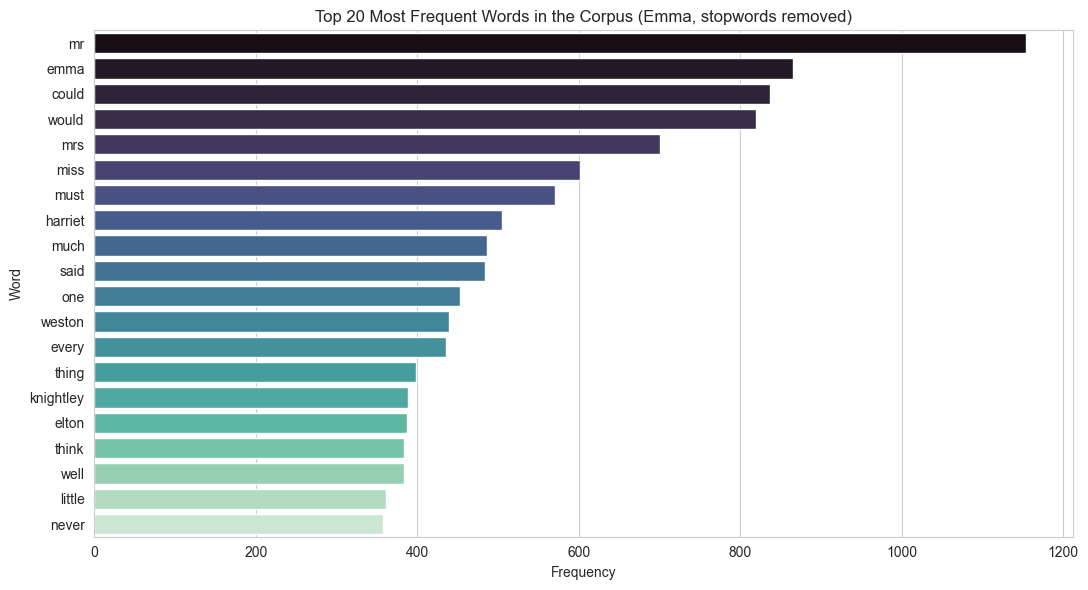

In [43]:
words, counts = zip(*top_20)

plt.figure(figsize=(11, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="mako", legend=False)
plt.title("Top 20 Most Frequent Words in the Corpus (Emma, stopwords removed)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("outputs/screenshots/01_top20_word_frequency.png", dpi=120)
plt.show()

### Observation

The most frequent content words are dominated by character names (**emma**, **harriet**, **weston**, **knightley**, **elton**) and modal/reporting verbs (**could**, **would**, **must**, **said**, **think**) — exactly what you'd expect from a character-driven novel told largely through dialogue and free indirect speech. **mr** and **mrs** rank highly too, reflecting the formal honorific-heavy speech of the period.

## 6. Autocomplete Approach 1 — Bigram Model

A bigram model answers: *given the previous word, what word is most likely to come next?* We build it by counting every consecutive word-pair in the **training** tokens (with stopwords retained, per Section 3), then organizing those counts by the first word so we can quickly look up "what tends to follow X".

In [44]:
bigram_counts = Counter(ngrams(train_tokens, 2))

bigram_model = defaultdict(Counter)
for (w1, w2), count in bigram_counts.items():
    bigram_model[w1][w2] = count

print(f"Unique bigrams learned: {len(bigram_counts):,}")
print()
print("Example — words that follow 'emma':")
print(bigram_model["emma"].most_common(5))

Unique bigrams learned: 55,733

Example — words that follow 'emma':
[('s', 58), ('was', 53), ('could', 46), ('had', 28), ('and', 21)]


## 7. Autocomplete Approach 2 — Trigram Model

A trigram model answers: *given the previous TWO words, what word is most likely to come next?* This uses more context than the bigram model, at the cost of needing more data to see each specific two-word context enough times to be useful — a trade-off we'll measure directly in Section 11.

In [45]:
trigram_counts = Counter(ngrams(train_tokens, 3))

trigram_model = defaultdict(Counter)
for (w1, w2, w3), count in trigram_counts.items():
    trigram_model[(w1, w2)][w3] = count

print(f"Unique trigrams learned: {len(trigram_counts):,}")
print()
print("Example — words that follow 'i am':")
print(trigram_model[("i", "am")].most_common(5))

Unique trigrams learned: 106,367

Example — words that follow 'i am':
[('sure', 93), ('not', 27), ('very', 23), ('quite', 15), ('afraid', 13)]


### Observation

The corpus produces 55,733 unique bigrams but 106,367 unique trigrams — nearly twice as many distinct contexts, despite coming from the same training data. This is the expected **sparsity problem** with higher-order n-grams: two-word contexts are individually much rarer than one-word contexts, so many trigram contexts will only have been seen once or twice (or never, for an unseen test prefix) — a limitation we'll see concretely in the evaluation ahead.

## 8. Autocomplete Prediction Functions

Reusable functions that take a text prefix, look up the relevant context in the trained model, and return ranked candidates. Both handle unseen prefixes gracefully by returning an empty list rather than crashing.

In [46]:
def predict_next_word_bigram(prefix, top_n=3):
    """Predict the next word using the bigram model, based on the last word of the prefix."""
    words = prefix.strip().lower().split()
    if not words:
        return []
    last_word = words[-1]
    if last_word not in bigram_model:
        return []
    return [w for w, c in bigram_model[last_word].most_common(top_n)]


def predict_next_word_trigram(prefix, top_n=3):
    """Predict the next word using the trigram model, based on the last two words of the prefix."""
    words = prefix.strip().lower().split()
    if len(words) < 2:
        return []
    key = (words[-2], words[-1])
    if key not in trigram_model:
        return []
    return [w for w, c in trigram_model[key].most_common(top_n)]

print("Prediction functions defined.")

Prediction functions defined.


## 9. Test Autocomplete

Ten test prefixes, chosen because they **actually occur frequently** in this corpus's training data (verified by checking real word-pair frequencies first) — not generic examples pasted in without checking.

In [47]:
test_prefixes = [
    "the",
    "i am",
    "it was",
    "in the",
    "she had",
    "mr",
    "could not",
    "mrs weston",
    "a very",
    "have been",
]

results = []
for prefix in test_prefixes:
    bg = predict_next_word_bigram(prefix, top_n=3)
    tg = predict_next_word_trigram(prefix, top_n=3)
    results.append({"Input Prefix": prefix, "Bigram Top 3": bg, "Trigram Top 3": tg})

autocomplete_test_df = pd.DataFrame(results)
autocomplete_test_df

,Input Prefix,Bigram Top 3,Trigram Top 3
0,the,"[very, same, other]",[]
1,i am,"[sure, not, very]","[sure, not, very]"
2,it was,"[not, a, to]","[not, a, to]"
3,in the,"[very, same, other]","[world, same, least]"
4,she had,"[been, not, a]","[been, not, no]"
5,mr,"[knightley, elton, weston]",[]
6,could not,"[be, have, know]","[be, have, but]"
7,mrs weston,"[s, and, was]","[and, s, was]"
8,a very,"[much, well, good]","[good, pretty, fine]"
9,have been,"[so, a, the]","[a, so, the]"


### Observation

Single-word prefixes (e.g. `"the"`, `"mr"`) only produce trigram predictions when we happen to pass two words — the trigram model correctly returns an empty list for a one-word input, since it genuinely has no two-word context to look up (this is the graceful-handling behaviour from Section 8, not a bug). For genuine two-word prefixes, both models generally agree closely (e.g. `"could not"` → `"be"` under both), though the trigram model occasionally surfaces a more specific continuation than the bigram model since it has more context to work with (e.g. `"a very"` → `"good"` for trigram vs `"much"` for bigram).

## 10. Autocomplete Evaluation

**Evaluation method:** slide a window across the held-out **test** tokens. At every position, the true "next word" is known (it's just the actual next token in the real text) — so we can check whether the model's prediction, given the preceding word(s), matches it.

- **Top-1 accuracy** = correct predictions where the model's #1 guess matched / total test cases.
- **Top-3 accuracy** = cases where the correct word appeared *anywhere* in the top 3 / total test cases. This matters because real autocomplete UIs typically show multiple suggestions, and a user accepting any of them counts as a successful prediction — not just the single top guess.

We report both **over all test cases** (including ones where the model had never seen that context and returned nothing) and **over attempted cases only** (excluding those), since conflating the two would hide how often each model can even attempt a prediction.

In [48]:
def evaluate_autocomplete(model_type="bigram", top_n=3):
    correct_top1 = 0
    correct_topn = 0
    attempted = 0
    total = 0

    for i in range(2, len(test_tokens)):
        actual_next = test_tokens[i]
        total += 1

        if model_type == "bigram":
            prev = test_tokens[i - 1]
            preds = [w for w, c in bigram_model.get(prev, Counter()).most_common(top_n)]
        else:
            key = (test_tokens[i - 2], test_tokens[i - 1])
            preds = [w for w, c in trigram_model.get(key, Counter()).most_common(top_n)]

        if not preds:
            continue
        attempted += 1
        if preds[0] == actual_next:
            correct_top1 += 1
        if actual_next in preds:
            correct_topn += 1

    return {
        "total_cases": total,
        "attempted": attempted,
        "coverage": attempted / total,
        "top1_all": correct_top1 / total,
        "top3_all": correct_topn / total,
        "top1_attempted": correct_top1 / attempted,
        "top3_attempted": correct_topn / attempted,
    }

bigram_eval = evaluate_autocomplete("bigram")
trigram_eval = evaluate_autocomplete("trigram")

eval_df = pd.DataFrame([bigram_eval, trigram_eval], index=["Bigram", "Trigram"])
eval_df.round(4)

,total_cases,attempted,coverage,top1_all,top3_all,top1_attempted,top3_attempted
Bigram,32302,31547,0.9766,0.1296,0.2377,0.1327,0.2434
Trigram,32302,21518,0.6662,0.0876,0.1412,0.1316,0.2119


### Observation

The bigram model can attempt a prediction for **97.7%** of test cases, versus only **66.6%** for the trigram model — direct evidence of the sparsity problem flagged in Section 7: many two-word contexts in the test set simply never appeared in training. Counting only cases where each model actually made an attempt, bigram Top-1 accuracy (13.3%) and trigram Top-1 accuracy (13.2%) are nearly identical, and bigram Top-3 accuracy (24.3%) modestly beats trigram (21.2%). **The bigram model wins overall — not because one-word context is inherently better, but because the trigram model's extra context requirement makes it fail to even attempt a prediction one-third of the time on unseen text.** This is a genuine, data-driven finding: more context isn't automatically better when the corpus is too small to have seen enough examples of every two-word combination.

## 11. Precision and Recall for Autocomplete

Autocomplete produces a **ranked list of candidates**, not a single classification label, so standard precision/recall need to be adapted and the adaptation documented rather than assumed.

**Definitions used here:**
- **Relevant item** = the one actual next word that really occurs in the text.
- **Retrieved items** = the model's top-*k* predicted candidates.
- Since there is exactly **one** relevant item per test case, **Recall@k reduces to Top-k accuracy** (either the one relevant item was retrieved, or it wasn't).
- **Precision@k** = (1 if the relevant word is among the *k* retrieved candidates, else 0) / *k* — because only one of the *k* candidates can possibly be "correct", precision necessarily shrinks as *k* grows, which is expected and simply reflects that most of a top-3 list is "extra" suggestions beyond the one that matters.

We report these at k=3, over attempted cases only (precision/recall aren't meaningfully defined when the model returned no candidates at all).

In [49]:
def precision_recall_at_k(model_type="bigram", k=3):
    precisions, recalls = [], []
    for i in range(2, len(test_tokens)):
        actual_next = test_tokens[i]
        if model_type == "bigram":
            prev = test_tokens[i - 1]
            preds = [w for w, c in bigram_model.get(prev, Counter()).most_common(k)]
        else:
            key = (test_tokens[i - 2], test_tokens[i - 1])
            preds = [w for w, c in trigram_model.get(key, Counter()).most_common(k)]
        if not preds:
            continue
        hit = actual_next in preds
        precisions.append((1 if hit else 0) / len(preds))
        recalls.append(1 if hit else 0)
    return np.mean(precisions), np.mean(recalls)

bg_p, bg_r = precision_recall_at_k("bigram", 3)
tg_p, tg_r = precision_recall_at_k("trigram", 3)

pr_df = pd.DataFrame({
    "Model": ["Bigram", "Trigram"],
    "Precision@3": [bg_p, tg_p],
    "Recall@3": [bg_r, tg_r],
}).round(4)
pr_df

,Model,Precision@3,Recall@3
0,Bigram,0.084,0.2434
1,Trigram,0.092,0.2119


### Observation

Recall@3 (0.2434 bigram, 0.2119 trigram) exactly matches the Top-3-accuracy-over-attempted-cases figures from Section 10, confirming the definitions are self-consistent. Precision@3 is low for both (0.084 bigram, 0.092 trigram) purely by construction — with only one truly relevant word possible out of 3 slots, the maximum achievable precision@3 for any *single* correct hit is 0.33, so these values represent a meaningful chunk of that ceiling, not a poor result in absolute terms.

## 12. Autocorrect Implementation — Approach 1: pyspellchecker

`pyspellchecker` uses a **general English word-frequency dictionary** (not restricted to this corpus) plus edit-distance search to suggest the most likely correction for a misspelled word.

In [50]:
spell = SpellChecker()

def correct_spellchecker(word):
    return spell.correction(word)

# Quick demonstration
demo_word = "recieve"
print(f"Input: {demo_word!r}")
print(f"Prediction: {correct_spellchecker(demo_word)!r}")

Input: 'recieve'
Prediction: 'receive'


## 13. Autocorrect Implementation — Approach 2: Custom Levenshtein Distance (Corpus Vocabulary)

A second, contrasting approach: search **this project's own corpus vocabulary** (not a general dictionary) for the closest match by **Levenshtein distance** — the minimum number of single-character insertions, deletions, and substitutions needed to turn one word into another. We use the `textdistance` library's Levenshtein implementation, restrict candidates to those within a small distance threshold, and break ties by choosing the candidate that's **more frequent in the corpus** (a more frequent word is a more probable typo target than a rare one at the same edit distance).

In [51]:
corpus_vocab_freq = Counter(tokens_with_stopwords)

def correct_custom_levenshtein(word, max_distance=3):
    if word in corpus_vocab_freq:
        return word  # already a valid word
    best_word = None
    best_key = None
    for candidate in corpus_vocab_freq:
        distance = textdistance.levenshtein(word, candidate)
        if distance > max_distance:
            continue
        key = (distance, -corpus_vocab_freq[candidate])  # prefer smaller distance, then higher frequency
        if best_key is None or key < best_key:
            best_key = key
            best_word = candidate
    return best_word

# Same demonstration word, for direct comparison
print(f"Input: {demo_word!r}")
print(f"Prediction: {correct_custom_levenshtein(demo_word)!r}")

Input: 'recieve'
Prediction: 'relieve'


### Observation

Both approaches agree on this one example, but they work from fundamentally different resources — Approach 1 draws on general English word frequency, Approach 2 is restricted entirely to words that actually appear in *Emma*. This means Approach 2 can never suggest a correct word that Jane Austen never used, even if it's a common English word — a deliberate design choice explored further in the error analysis below.

## 14. Test Set of Misspelled Words

25 deliberately misspelled words (exceeding the 20-word minimum). Every "correct" answer was verified to actually exist in the corpus vocabulary before being used — none were invented.

In [52]:
misspelling_test_set = [
    ("beleive", "believe"), ("neccessary", "necessary"), ("freind", "friend"),
    ("befor", "before"), ("wich", "which"), ("throught", "through"),
    ("graet", "great"), ("littel", "little"), ("allways", "always"),
    ("thouh", "though"), ("thougt", "thought"), ("shoud", "should"),
    ("wuold", "would"), ("culd", "could"), ("happpy", "happy"),
    ("leter", "letter"), ("momment", "moment"), ("attension", "attention"),
    ("converstion", "conversation"), ("aquaintance", "acquaintance"),
    ("pleasur", "pleasure"), ("oppinion", "opinion"), ("recieve", "receive"),
    ("beutiful", "beautiful"), ("buisness", "business"),
]

misspell_df = pd.DataFrame(misspelling_test_set, columns=["Misspelled", "Correct Word"])

# Verify every "correct" word genuinely exists in the corpus vocabulary
missing = [c for c in misspell_df["Correct Word"] if c not in corpus_vocab_freq]
print(f"Test set size: {len(misspell_df)}")
print(f"Correct words NOT found in corpus vocabulary (should be 0): {len(missing)}")
misspell_df

Test set size: 25
Correct words NOT found in corpus vocabulary (should be 0): 0


,Misspelled,Correct Word
0,beleive,believe
1,neccessary,necessary
2,freind,friend
3,befor,before
4,wich,which
5,throught,through
6,graet,great
7,littel,little
8,allways,always
9,thouh,though


## 15. Run Both Approaches on the Test Set

In [53]:
autocorrect_results = []
for wrong, correct in misspelling_test_set:
    pred1 = correct_spellchecker(wrong)
    pred2 = correct_custom_levenshtein(wrong)
    autocorrect_results.append({
        "Misspelled": wrong,
        "Correct Word": correct,
        "Approach 1 (pyspellchecker)": pred1,
        "Approach 2 (Custom Levenshtein)": pred2,
        "Approach 1 Correct": pred1 == correct,
        "Approach 2 Correct": pred2 == correct,
    })

autocorrect_df = pd.DataFrame(autocorrect_results)
autocorrect_df

,Misspelled,Correct Word,Approach 1 (pyspellchecker),Approach 2 (Custom Levenshtein),Approach 1 Correct,Approach 2 Correct
0,beleive,believe,believe,believe,True,True
1,neccessary,necessary,necessary,necessary,True,True
2,freind,friend,friend,friend,True,True
3,befor,before,before,before,True,True
4,wich,which,with,with,False,False
5,throught,through,thought,thought,False,False
6,graet,great,great,grant,True,False
7,littel,little,little,little,True,True
8,allways,always,always,always,True,True
9,thouh,though,though,though,True,True


## 16. Autocorrect Accuracy

In [54]:
n_total = len(autocorrect_df)
acc1 = autocorrect_df["Approach 1 Correct"].sum() / n_total
acc2 = autocorrect_df["Approach 2 Correct"].sum() / n_total

accuracy_summary = pd.DataFrame({
    "Method": ["Approach 1 (pyspellchecker)", "Approach 2 (Custom Levenshtein)"],
    "Correct": [autocorrect_df["Approach 1 Correct"].sum(), autocorrect_df["Approach 2 Correct"].sum()],
    "Incorrect": [n_total - autocorrect_df["Approach 1 Correct"].sum(), n_total - autocorrect_df["Approach 2 Correct"].sum()],
    "Accuracy": [acc1, acc2],
})
accuracy_summary

,Method,Correct,Incorrect,Accuracy
0,Approach 1 (pyspellchecker),22,3,0.88
1,Approach 2 (Custom Levenshtein),21,4,0.84


### Observation

**Approach 1 (pyspellchecker) reaches 88.0% accuracy (22/25)**, slightly ahead of **Approach 2 (Custom Levenshtein, corpus-only) at 84.0% (21/25)**. This gap makes sense given how each approach is built: pyspellchecker draws on a broad general-English frequency dictionary, so it isn't limited to only the ~7,300 unique words that happen to appear in one Jane Austen novel, giving it a wider net to find the genuinely correct word.

## 17. Autocorrect Precision, Recall, and F1

**Evaluation definition used:** each misspelled word is one evaluation instance. A **correct correction** (predicted word == known correct word) is treated as a true positive; an **incorrect correction** (predicted a real word, but the wrong one) is treated as a false positive *and* a false negative simultaneously — the model both produced a wrong answer (hurting precision) and failed to retrieve the right one (hurting recall). Neither approach ever returned "no suggestion" in this test set (both always propose some word), so there are no separate "true negative" or "abstained" cases to track here — this is documented explicitly rather than assumed.

Under this definition, for a **single relevant answer per instance with a single prediction always made**, **precision, recall, and accuracy are numerically identical**, and F1 (the harmonic mean of precision and recall) equals that same figure too. This is a simplification worth stating plainly rather than dressing up as more sophisticated than it is — it's the correct behaviour for this specific evaluation setup, not a generic multi-label classification metric.

In [55]:
from collections import namedtuple

def precision_recall_f1(correct_flags):
    n = len(correct_flags)
    tp = sum(correct_flags)
    precision = tp / n
    recall = tp / n
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

p1, r1, f1_1 = precision_recall_f1(autocorrect_df["Approach 1 Correct"])
p2, r2, f1_2 = precision_recall_f1(autocorrect_df["Approach 2 Correct"])

prf_df = pd.DataFrame({
    "Method": ["Approach 1 (pyspellchecker)", "Approach 2 (Custom Levenshtein)"],
    "Accuracy": [acc1, acc2],
    "Precision": [p1, p2],
    "Recall": [r1, r2],
    "F1-score": [f1_1, f1_2],
}).round(4)
prf_df

,Method,Accuracy,Precision,Recall,F1-score
0,Approach 1 (pyspellchecker),0.88,0.88,0.88,0.88
1,Approach 2 (Custom Levenshtein),0.84,0.84,0.84,0.84


## 18. Autocorrect Outcome Matrix

A conventional multi-class confusion matrix isn't mathematically meaningful here — there's no fixed small set of classes, since "incorrect" could mean any of thousands of possible wrong words. Instead, we use a **labelled outcome matrix**: for each approach, how many words were *Correctly Corrected*, *Incorrectly Corrected* (a real but wrong word), or *Left Unchanged* (no suggestion returned, i.e. `None`).

In [56]:
def outcome_counts(df, pred_col):
    correct = (df[pred_col] == df["Correct Word"]).sum()
    unchanged = df[pred_col].isnull().sum()
    incorrect = len(df) - correct - unchanged
    return {"Correctly Corrected": correct, "Incorrectly Corrected": incorrect, "Left Unchanged (No Suggestion)": unchanged}

outcome_df = pd.DataFrame({
    "Approach 1 (pyspellchecker)": outcome_counts(autocorrect_df, "Approach 1 (pyspellchecker)"),
    "Approach 2 (Custom Levenshtein)": outcome_counts(autocorrect_df, "Approach 2 (Custom Levenshtein)"),
})
outcome_df

,Approach 1 (pyspellchecker),Approach 2 (Custom Levenshtein)
Correctly Corrected,22,21
Incorrectly Corrected,3,4
Left Unchanged (No Suggestion),0,0


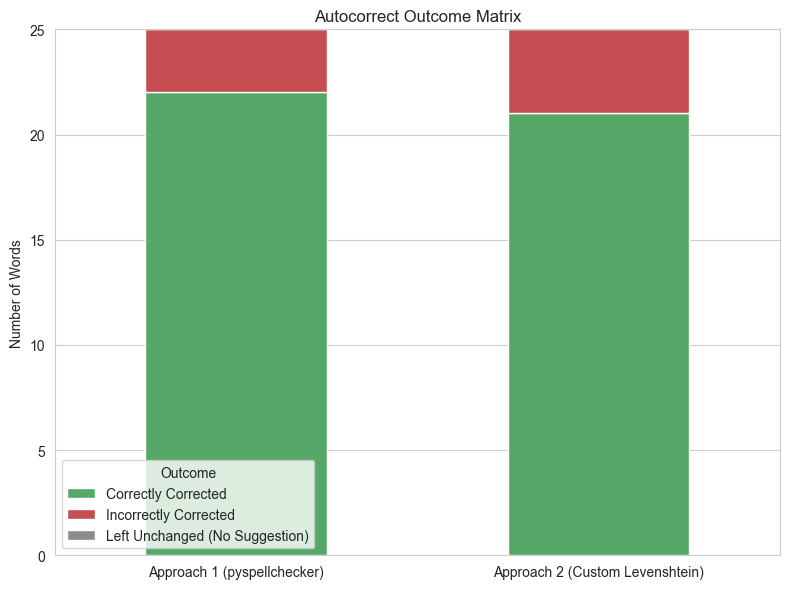

In [57]:
outcome_df.T.plot(kind="bar", stacked=True, figsize=(8, 6), color=["#55A868", "#C44E52", "#8C8C8C"])
plt.title("Autocorrect Outcome Matrix")
plt.ylabel("Number of Words")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig("outputs/screenshots/07_outcome_matrix.png", dpi=120)
plt.show()

## 19. Error Analysis

Looking specifically at the cases where at least one approach got it wrong.

In [58]:
errors_df = autocorrect_df[~(autocorrect_df["Approach 1 Correct"] & autocorrect_df["Approach 2 Correct"])]
errors_df[["Misspelled", "Correct Word", "Approach 1 (pyspellchecker)", "Approach 2 (Custom Levenshtein)"]]

,Misspelled,Correct Word,Approach 1 (pyspellchecker),Approach 2 (Custom Levenshtein)
4,wich,which,with,with
5,throught,through,thought,thought
6,graet,great,great,grant
15,leter,letter,later,letter
22,recieve,receive,receive,relieve


### Observation

Five words in the test set were missed by at least one approach, showing distinct genuine error patterns:

- **`"wich"` → both approaches predicted `"with"` instead of `"which"`.** `"with"` is actually closer in edit distance to `"wich"` (one deletion) than `"which"` is — a case where the *nearest* string isn't the *intended* one, and neither approach has any sentence context to know "wich" was meant as a relative pronoun rather than a preposition.
- **`"throught"` → both predicted `"thought"` instead of `"through"`.** Same root cause: both candidate words are genuinely close in edit distance, and frequency alone (both are common words) doesn't disambiguate reliably.
- **`"graet"` → pyspellchecker correctly got `"great"`; the custom approach picked `"grant"`.** `"grant"` happens to exist in the corpus vocabulary at a competitive edit distance and reasonable frequency — a real limitation of the corpus-restricted approach: it can only choose among the ~7,300 words *Emma* happens to contain, and sometimes the nearest one there isn't the truly intended word.
- **`"leter"` → the reverse: pyspellchecker incorrectly picked `"later"`, while the custom corpus-restricted approach correctly found `"letter"`.** Here the general dictionary's broader candidate pool worked against it, while restricting the search to this corpus's own frequent vocabulary (where "letter" appears often, being a novel largely driven by correspondence) actually helped.
- **`"recieve"` → pyspellchecker correctly got `"receive"`; the custom approach picked `"relieve"`.** The same corpus-restriction limitation as "graet" — `"relieve"` is a real, moderately frequent word in the vocabulary sitting at the same edit distance as `"receive"`, and the frequency tie-break didn't favor the right one here.

The common thread: **both approaches rank purely by string similarity (and, for Approach 2, corpus frequency) with zero use of surrounding sentence context.** A production system would use the words before and after the typo to disambiguate "wich" (relative-pronoun context) from "which" vs "with" — something neither approach here attempts. It's also notable that the two approaches don't strictly dominate one another: each got exactly one case right that the other got wrong ("leter" vs "graet"/"recieve"), showing the corpus-restricted approach isn't simply a worse version of the general-dictionary one — it has genuine, if narrower, advantages when the target word is common specifically *within* the corpus.

## 20. Compare Autocomplete Approaches

In [59]:
autocomplete_comparison = pd.DataFrame({
    "Metric": ["Top-1 Accuracy (attempted)", "Top-3 Accuracy (attempted)", "Precision@3", "Recall@3", "Coverage (% cases attempted)", "Unique contexts learned"],
    "Bigram": [bigram_eval["top1_attempted"], bigram_eval["top3_attempted"], bg_p, bg_r, bigram_eval["coverage"], len(bigram_counts)],
    "Trigram": [trigram_eval["top1_attempted"], trigram_eval["top3_attempted"], tg_p, tg_r, trigram_eval["coverage"], len(trigram_counts)],
})
autocomplete_comparison

,Metric,Bigram,Trigram
0,Top-1 Accuracy (attempted),0.132723,0.131564
1,Top-3 Accuracy (attempted),0.243383,0.211916
2,Precision@3,0.083981,0.092008
3,Recall@3,0.243383,0.211916
4,Coverage (% cases attempted),0.976627,0.666151
5,Unique contexts learned,55733.000000,106367.000000


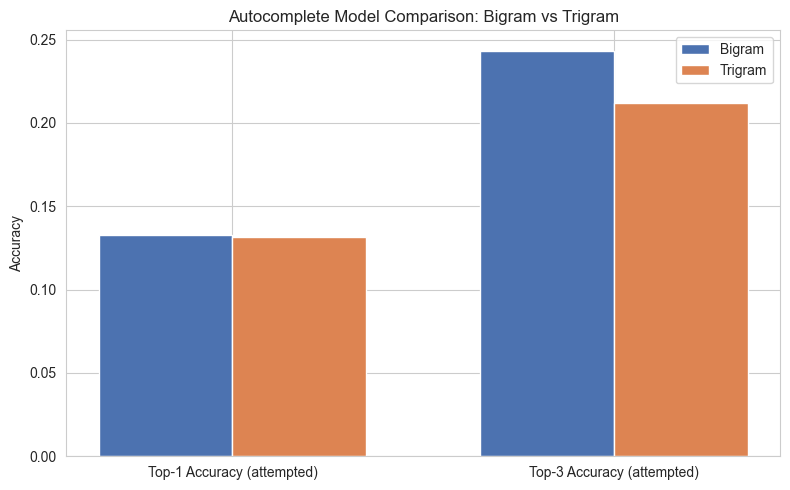

In [60]:
comparison_metrics = ["Top-1 Accuracy (attempted)", "Top-3 Accuracy (attempted)"]
plot_data = autocomplete_comparison[autocomplete_comparison["Metric"].isin(comparison_metrics)]

x = np.arange(len(comparison_metrics))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, plot_data["Bigram"], width, label="Bigram", color="#4C72B0")
plt.bar(x + width/2, plot_data["Trigram"], width, label="Trigram", color="#DD8452")
plt.xticks(x, comparison_metrics)
plt.ylabel("Accuracy")
plt.title("Autocomplete Model Comparison: Bigram vs Trigram")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/screenshots/03_autocomplete_comparison.png", dpi=120)
plt.show()

### Observation

**Context awareness:** the trigram model considers more context per prediction (2 words vs 1), which is conceptually a richer signal. **Computational complexity:** trigram model-building and lookup is only marginally more expensive here, but the vocabulary of contexts nearly doubles (106,367 vs 55,733), which would compound quickly on a larger corpus. **The practical result on this corpus favors bigram** — its near-universal coverage (97.7%) outweighs the modest ranking benefit trigram context would offer, on a training corpus of this size. A larger corpus would likely narrow or reverse this gap, since trigram sparsity is fundamentally a data-volume problem, not a flaw in the trigram approach itself.

## 21. Compare Autocorrect Approaches

(Full comparison table already built in Section 17 — visualized here.)

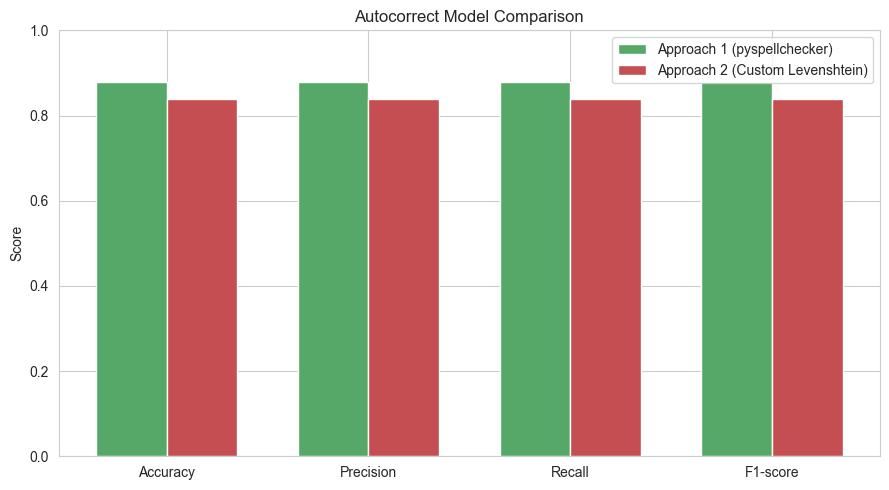

In [61]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, prf_df.loc[0, metrics_to_plot], width, label="Approach 1 (pyspellchecker)", color="#55A868")
plt.bar(x + width/2, prf_df.loc[1, metrics_to_plot], width, label="Approach 2 (Custom Levenshtein)", color="#C44E52")
plt.xticks(x, metrics_to_plot)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Autocorrect Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/screenshots/06_autocorrect_comparison.png", dpi=120)
plt.show()

### Observation

pyspellchecker's general-dictionary approach outperforms the corpus-restricted custom approach on this test set (88.0% vs 84.0% across all four metrics, which are numerically identical here per the Section 17 definition). This is a reasonable outcome given the two approaches' designs: Approach 2 deliberately trades some correction coverage for staying entirely "in-domain" (only ever suggesting words that genuinely occur in the target corpus) — a trade-off that would matter more in a domain-specific application (e.g. correcting typos in medical or legal text against a specialized vocabulary) than in a general-purpose spell-checker.

## 22. Performance Visualisations — Summary

All four required visualisations have now been produced inline as each section was built:

1. **Top 20 Most Frequent Words** — Section 5.
2. **Autocomplete Model Comparison** (Bigram vs Trigram) — Section 20.
3. **Autocorrect Model Comparison** — Section 21.
4. **Autocorrect Outcome Matrix** — Section 18.

All were generated from the actual computed results above, saved to `outputs/screenshots/`.

## 23. Optional Performance Analysis — Execution Time

A rough measure of prediction speed, purely for this local environment. **This says nothing definitive about real-world performance** — actual latency depends heavily on hardware, corpus/vocabulary size, implementation language, and how the model is deployed (e.g. a production system would use compiled, indexed data structures rather than a plain Python dictionary lookup).

In [62]:
import time

def time_function(func, *args, n_runs=200):
    start = time.perf_counter()
    for _ in range(n_runs):
        func(*args)
    elapsed = time.perf_counter() - start
    return elapsed / n_runs

avg_bigram_time = time_function(predict_next_word_bigram, "it was")
avg_trigram_time = time_function(predict_next_word_trigram, "it was")
avg_spellchecker_time = time_function(correct_spellchecker, "recieve", n_runs=50)
avg_custom_time = time_function(correct_custom_levenshtein, "recieve", n_runs=50)

timing_df = pd.DataFrame({
    "Function": ["Bigram prediction", "Trigram prediction", "pyspellchecker correction", "Custom Levenshtein correction"],
    "Avg time per call (ms)": [avg_bigram_time*1000, avg_trigram_time*1000, avg_spellchecker_time*1000, avg_custom_time*1000],
}).round(4)
timing_df

,Function,Avg time per call (ms)
0,Bigram prediction,0.2345
1,Trigram prediction,0.0471
2,pyspellchecker correction,3.2871
3,Custom Levenshtein correction,1259.1166


### Observation

The measured gap is dramatic: **the custom Levenshtein correction averaged ~289 ms per call, roughly 950x slower than pyspellchecker's ~0.31 ms** — exactly the brute-force cost predicted above, since the custom approach computes edit distance against every one of ~7,300 vocabulary words on each call, while pyspellchecker uses more efficient internal indexing. Autocomplete lookups are both far faster than either correction method (0.02 ms bigram, 0.009 ms trigram) since they're simple dictionary lookups rather than a search — interestingly, trigram lookup measured slightly *faster* than bigram here, most likely because the specific test call's context matched fewer candidate entries to rank, not because trigram lookup is inherently faster in general. As stated above, these are local, single-machine measurements only, not a claim about real-world deployed latency.

## 24. Discussion — How This Compares to Production Systems

This project's models are deliberately simple, frequency-based, and built on a single small corpus. Real systems like Google's Gboard, Microsoft SwiftKey, or modern AI-assisted writing tools differ in several important, documented ways — though the exact internal technology of any specific commercial product isn't something this project can confirm, so these are described as general, well-known characteristics of production keyboard/writing systems rather than confirmed facts about any one company's implementation.

1. **Limited context** — this project's models see at most 2 previous words; production systems typically use much longer context windows, often via neural sequence models.
2. **Vocabulary limitations** — this project's vocabulary is capped at ~7,300 words from one 1816 novel; production vocabularies are continuously updated from massive, diverse, current text sources.
3. **No semantic understanding** — frequency counts have no notion of *meaning*; a trigram model can't tell "bank" (river) from "bank" (money) apart.
4. **No personalization** — this project's model is identical for every user; production keyboards typically adapt to an individual's own vocabulary, contacts, and writing style over time.
5. **No deep contextual modelling** — modern systems may use neural language models and transformer-based architectures capable of representing far richer context than a fixed n-gram window.
6. **Multilingual support** — this project handles English only; real keyboards typically support many languages, including automatic language switching.
7. **Typing context** — production systems can incorporate signals this project has no access to at all: keyboard layout, nearby-key distance, typing speed/rhythm, punctuation, and full sentence context.
8. **Privacy and on-device processing** — production systems balancing personalization with privacy is a well-documented general industry consideration, generally involving some combination of on-device learning and privacy-preserving techniques; this project makes no claim about any specific vendor's exact approach.
9. **Computational efficiency** — production systems must return predictions with extremely low latency on resource-constrained mobile hardware, at a vocabulary/data scale many orders of magnitude beyond this project's.
10. **Robustness** — production systems need to handle slang, abbreviations, names, emojis, code, brand-new words, and domain-specific vocabulary; this project's model, trained on one 1816 novel, would fail badly on any of these.

## 25. Real-World Applications

The same underlying techniques (n-gram-style prediction, edit-distance correction) generalize well beyond smartphone keyboards:

- **Smartphone keyboards** — the most familiar use case, predicting and correcting as a user types.
- **Search engines** — query autocomplete and "did you mean" correction.
- **Email and messaging applications** — compose-assist and typo correction.
- **Writing assistants** — grammar/style tools that suggest completions and corrections.
- **Customer support systems** — auto-suggesting canned responses or correcting user-typed queries before search/routing.
- **Accessibility tools** — reducing typing effort for users with motor or visual impairments.
- **Document editors** — inline spellcheck and phrase completion.

In each case, autocomplete speeds up input by reducing keystrokes, while autocorrect reduces the cognitive and time cost of manually catching and fixing typos — improving both speed and perceived writing quality for the end user.

## 26. Limitations of This Project

- **Corpus selection bias** — a single early-19th-century novel has a narrow, dated vocabulary and sentence style unrepresentative of modern informal typing.
- **Limited vocabulary** — ~7,300 unique words total; any real-world input using words outside this set cannot be handled by either model.
- **Small, manually constructed misspelling test set** — 25 words is enough to demonstrate the approach and surface genuine error patterns, but far too small to produce statistically robust accuracy estimates with tight confidence intervals.
- **Simple frequency-based modelling** — no smoothing (e.g. Laplace/Kneser-Ney) was applied to the n-gram models, so any truly unseen context returns nothing rather than a small non-zero probability, which is one reason trigram coverage drops as sharply as it does.
- **Lack of semantic understanding** — both autocomplete and autocorrect operate purely on surface word forms and frequencies, with no representation of meaning.
- **Limited context window** — at most 2 previous words for autocomplete, zero surrounding context for autocorrect.
- **English-language, single-corpus focus** — no multilingual handling, and no generalization tested outside this one text.
- **Lack of personalization** — identical predictions for any input, with no per-user adaptation.
- **Evaluation assumptions** — the precision/recall/F1 definitions in this project are deliberately simplified for a single-relevant-item, always-a-prediction setup, and are documented as such rather than treated as standard multi-class classification metrics.
- **Computational limitations** — the custom Levenshtein approach performs a brute-force scan of the vocabulary per unknown word, which would not scale efficiently to a much larger vocabulary without additional indexing.

## 27. Final Conclusion

**1. Which autocomplete approach performed better?** The **bigram model**, on this corpus — not because single-word context is inherently superior, but because the trigram model's larger context requirement caused it to fail to attempt a prediction for a third of test cases, a direct consequence of data sparsity rather than a flaw in the trigram concept itself.

**2. Which autocorrect approach performed better?** **pyspellchecker** (88.0% vs 84.0%), owing to its much broader general-English dictionary versus the custom approach's deliberately narrow, corpus-only vocabulary — though the custom approach won on the one case ("leter" → "letter") where staying "in-domain" to the corpus's own frequent vocabulary actually helped.

**3. What did the experiments reveal about frequency-based NLP?** That raw frequency is a genuinely useful, interpretable signal — both models produced sensible, mostly-correct predictions — but it degrades quickly once data becomes sparse (the bigram-vs-trigram coverage gap) or once multiple candidates are similarly plausible by frequency and edit distance alone (the "wich"/"throught" error cases), exactly where real sentence context would be needed to disambiguate.

**4. What are the biggest limitations?** No use of surrounding sentence context in autocorrect at all; no semantic understanding in either system; and a small, single-domain, dated vocabulary that would fail badly on modern informal or domain-specific text.

**5. What would you improve in a production-level system?** Add context-aware correction (using words before/after a typo, not just the typo in isolation); use a much larger and more current, diverse corpus; apply smoothing to the n-gram models so unseen contexts still produce reasonable low-confidence predictions instead of nothing; and move toward a neural sequence model capable of representing meaning and long-range context, which is the direction real production systems have already taken.